In [1]:
import os
import torch
import numpy as np
from extract import extract_graph, extract_die_area, load_file_content
import scipy.sparse as sp 
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking , load_cts_parameters
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = "dataset_with_def/placement_files/"
csv_dir = "dataset_with_def/"



In [2]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

class FirstTerm(nn.Module):
    def __init__(self, num_cell_types, num_of_clusters , embedding_dim=8):
        super().__init__()
        self.cell_embedding = nn.Embedding(num_cell_types, embedding_dim)
        # Initialize 10.9M weights (The Dials)
        feature_dim = 18 + embedding_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(feature_dim*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        nn.init.normal_(self.edge_mlp[2].weight, mean=0.0, std=0.001)
        nn.init.constant_(self.edge_mlp[2].bias, 0.01)


        # 3. THE CLUSTER HEAD (The C-Matrix Generator)
        # This replaces the N x K parameter bottleneck.
        self.cluster_head = nn.Sequential(
            nn.Linear(18 + embedding_dim, 64), 
            nn.ReLU(),
            nn.Linear(64, num_of_clusters)      # Output is K clusters
        )



    def forward(self, X, X_cell_ids, num_nodes, p_indices, A_skip_csr, current_k, tau=1.0):
        
        X_cell_ids = X_cell_ids.squeeze()
        cell_features = self.cell_embedding(X_cell_ids)  # Shape: [num_nodes, embedding_dim]
        X_combined = torch.cat([X, cell_features], dim=1)  # Shape: [num_nodes, 18 + embedding_dim]

        src_features = X_combined[p_indices[0]]  # Shape: [num_edges, feature_dim]
        dst_features = X_combined[p_indices[1]]  # Shape: [num_edges, feature_dim]
        edge_inputs = torch.cat([src_features, dst_features], dim=1)  # Shape: [num_edges, feature_dim*2]

        dynamic_p_weights = self.edge_mlp(edge_inputs).squeeze(-1)
        safe_weights = F.softplus(dynamic_p_weights) 


        # Enforce P >= 0 and build sparse matrix
        P = torch.sparse_coo_tensor(p_indices, safe_weights, 
                                    (num_nodes, num_nodes)).coalesce()
        
        # Reconstruction: XP
        X_hat = torch.sparse.mm(P, X)
        
        # Loss: ||X - XP||
        error = X - X_hat
        loss1 = torch.mean(error**2)   

        # Pass all node features through the head
        logits = self.cluster_head(X_combined) # Shape: [n, k]

        logits = logits[:, :current_k]
        
        #TERM2
        #C matrix with probability distribution across clusters for each node
        C = F.gumbel_softmax(logits, tau=tau, hard=False) # Shape: [n, k]
        # C = F.softmax(logits, dim=-1)  # Ensure positivity for SDDMM

        p_vals = P.values()
        
        # 1. Sum across rows (dim=1) to get the total weight leaving each node
        row_sums = torch.sparse.sum(P, dim=1).to_dense()
        
        # 2. Expand row_sums to match the non-zero values 
        # P.indices()[0] contains the row index for every specific edge
        p_vals_norm = p_vals / (row_sums[P.indices()[0]] + 1e-8)
        
        # Rebuild using the exact same sorted indices
        P_norm = torch.sparse_coo_tensor(P.indices(), p_vals_norm, 
                                         (num_nodes, num_nodes)).coalesce()
        
        # 2. Convert to CSR format (Required for the CUDA SDDMM engine)
        P_csr = P_norm.to_sparse_csr()
        
        # 3. SDDMM Magic! 
        # beta=1.0, alpha=-1.0 calculates exactly: (1.0 * P_csr) - (1.0 * C @ C^T)
        # It ONLY calculates this at the 10.9M non-zero locations!
        diff_csr = torch.sparse.sampled_addmm(P_csr, C, C.t(), beta=1.0, alpha=-1.0)
        
        # 4. Square the differences and sum them
        loss2 = torch.sum(diff_csr.values() ** 2)


        #TERM3
        M = torch.matmul(C.t(), torch.sparse.mm(A_skip_csr, C))  # [k, n] @ [n, n] @ [n, k] -> [k, k]
        # 2. Normalize M into a probability distribution (M_tilde)
        M = torch.clamp(M, min=0)
        M_tilde = M / (M.sum() + 1e-8)
        loss3 = -torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        # 3. Calculate Shannon Entropy: -sum(p * log(p))
        # We only calculate for non-zero entries to avoid log(0)
        # loss3 = torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        

        alpha_1 = 1.0 
        alpha_2 = 1.0    
        alpha_3 = 1.0    
        loss = alpha_1* loss1 + (alpha_2 * loss2) +(alpha_3 * loss3) 


        return  loss, loss1 , loss2, loss3,  C , X_combined


import math
def get_tau(epoch):
    tau_start = 2.0
    tau_mid = 1.35   # Targets ~25% Confidence for the middle flatline
    tau_end = 0.85   # Targets ~40% Confidence for the final floor

    if epoch < 75:
        # Phase 1: Smooth descent to the middle flatline
        progress = epoch / 75.0
        return tau_mid + 0.5 * (tau_start - tau_mid) * (1 + math.cos(math.pi * progress))
        
    elif epoch < 150:
        # Phase 2: THE MIDDLE FLATLINE (Epoch 75 to 150)
        return tau_mid
        
    elif epoch < 200:
        # Phase 3: Smooth descent to the final floor
        progress = (epoch - 150) / 50.0
        return tau_end + 0.5 * (tau_mid - tau_end) * (1 + math.cos(math.pi * progress))
        
    else:
        # Phase 4: THE FINAL FLATLINE (Epoch 200 to 250+)
        return tau_end

In [ ]:
from helper import relative_masking
import random , os
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking , load_cts_parameters

# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# according to number of your cts knobs
NUM_CTS_KNOBS = 4 
metadata = torch.load("global_metadata.pt")
global_max_cell_types = metadata['global_max_cell_types']
global_max_k = metadata['global_max_k']

model = FirstTerm(num_cell_types=global_max_cell_types, num_of_clusters=global_max_k).to(device)
# gnn_model = HeteroCTS_GNN(input_dim=28, hidden_dim=64, num_params=NUM_CTS_KNOBS).to(device)

# FIXED: Optimizer now tracks BOTH models for Joint Optimization 
# optimizer = optim.Adam(list(model.parameters()) + list(gnn_model.parameters()), lr=0.01)

# ONLY track Phase 1 for this script
optimizer = optim.Adam(model.parameters(), lr=0.01)

processed_dir = "processed_graphs"
# List all processed file names
design_files = [f for f in os.listdir(processed_dir) if f.endswith('.pt')]

grouped_designs = {}
for f in design_files:
    # Splits "aes_run_20260306..." to extract just "aes"
    base_name = f.split('_run_')[0] 
    if base_name not in grouped_designs:
        grouped_designs[base_name] = []
    grouped_designs[base_name].append(f)

# 2. Pick exactly 5 from each category
balanced_files = []
for name, files in grouped_designs.items():
    random.shuffle(files)          # Shuffle within the category
    selected = files[:5]           # Take exactly 5 (or less if a category has < 5)
    balanced_files.extend(selected)

# 3. Final shuffle so the epoch isn't ordered by chip type
random.shuffle(balanced_files)
design_files = balanced_files      # Overwrite the main list

print(f"🔥 Fast-Tracking on {len(design_files)} perfectly balanced designs!")
# Quick check to prove it's balanced
print("Balance Check:", {name: len([x for x in design_files if name in x]) for name in grouped_designs.keys()})

# ==========================================
# RAM CACHING: Pre-load the 20 chips into System Memory
# ==========================================
print("\n📦 Pre-loading mini-dataset into System RAM to maximize speed...")
ram_cache = []

for filename in design_files:
    # map_location='cpu' guarantees it stays in your 16GB/32GB System RAM, protecting the 8GB GPU
    data = torch.load(os.path.join(processed_dir, filename), map_location='cpu')
    ram_cache.append((filename, data))
    
print("✅ Pre-loading complete! Starting training loop...\n")
 

for epoch in range(251):
    
    current_tau = get_tau(epoch)
    
    # Added confidence tracker
    total_l, l1_sum, l2_sum, l3_sum, conf_sum = 0, 0, 0, 0, 0
    total_task_loss, total_skew_l, total_power_l, total_wl_l = 0, 0, 0, 0 
    
    for i, (filename,data) in enumerate(ram_cache):
        
        optimizer.zero_grad()

        # 3. TRANSFER: Move ONLY what you need to the GPU
        X = data['X'].to(device)
        X_cell_ids = data['X_cell_ids'].to(device , non_blocking=True)
        p_indices = data['p_indices'].to(device, non_blocking=True)
        A_skip_csr = data['A_skip_csr'].to(device, non_blocking=True)
        A_wire_csr = data['A_wire_csr'].to(device, non_blocking=True)


        loss, l1, l2, l3, C , X_combined = model(
            X, 
            X_cell_ids,
            data['num_nodes'], 
            p_indices, 
            A_skip_csr,
            data['current_k'],
            tau=current_tau
        )


# ----------------------------------------
    # CORRECTED LOGGING BLOCK
    # ----------------------------------------
    if epoch % 10 == 0:
        n = len(design_files)
        log_str = (f"Epoch {epoch:3} | Base Loss: {total_l/n:.4f} | "
                   f"L1: {l1_sum/n:.4f} | L2: {l2_sum/n:.4f} | L3: {l3_sum/n:.4f} | "
                   f"Conf: {(conf_sum/n)*100:.2f}%")    
                   
        print(log_str)

torch.save(model.state_dict(), "phase1_clustering_ep250.pt")
print("✅ Saved! Ready to load these into the Joint-Optimization script.")   

🔥 Fast-Tracking on 20 perfectly balanced designs!
Balance Check: {'sha256': 5, 'aes': 5, 'ethmac': 5, 'picorv32': 5}

📦 Pre-loading mini-dataset into System RAM to maximize speed...


/home/rain/CTS-Task-Aware-Clustering/venv/lib/python3.12/site-packages/torch/_utils.py:361: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  result = torch.sparse_compressed_tensor(


✅ Pre-loading complete! Starting training loop...

Epoch   0 | Base Loss: 6406.0781 | L1: 6327.0432 | L2: 66.3353 | L3: 12.6997 | Conf: 4.27%
Epoch  10 | Base Loss: 63.6191 | L1: 4.1546 | L2: 47.4874 | L3: 11.9771 | Conf: 6.45%
Epoch  20 | Base Loss: 53.7399 | L1: 2.3167 | L2: 39.6209 | L3: 11.8023 | Conf: 7.08%
Epoch  30 | Base Loss: 51.2230 | L1: 1.4887 | L2: 38.0014 | L3: 11.7329 | Conf: 8.09%
Epoch  40 | Base Loss: 53.2887 | L1: 1.1232 | L2: 40.3871 | L3: 11.7784 | Conf: 9.48%
Epoch  50 | Base Loss: 58.4629 | L1: 0.9516 | L2: 45.6423 | L3: 11.8690 | Conf: 11.00%
Epoch  60 | Base Loss: 66.1871 | L1: 0.8700 | L2: 53.3190 | L3: 11.9981 | Conf: 12.44%
Epoch  70 | Base Loss: 70.9506 | L1: 0.8273 | L2: 57.9097 | L3: 12.2137 | Conf: 13.33%
Epoch  80 | Base Loss: 71.7877 | L1: 0.7983 | L2: 58.8175 | L3: 12.1719 | Conf: 13.35%
Epoch  90 | Base Loss: 71.0249 | L1: 0.7750 | L2: 58.1787 | L3: 12.0712 | Conf: 13.38%
Epoch 100 | Base Loss: 70.9716 | L1: 0.7621 | L2: 58.0932 | L3: 12.1163 | Conf:

In [5]:
#load the model
import torch
import os
import random
from helper import get_compressed_graph, relative_masking

# ==========================================
# 1. SETUP AND LOAD MODEL
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
metadata = torch.load("global_metadata.pt")

print("⚙️ Loading Phase 1 Model...")
# Initialize the architecture exactly as before
# THIS HARDCODES THE EXACT SHAPE OF YOUR PRE-TRAINED BRAIN (GOOD)
model = FirstTerm(num_cell_types=425,   # The global max cell types from your 20-chip dataset
                  num_of_clusters=1000  # The global max K from your 20-chip dataset
                 ).to(device)

# Load the trained weights
model.load_state_dict(torch.load("phase1_clustering_ep250.pt", map_location=device))

# CRITICAL: Put the model in evaluation mode (disables dropout, fixes batchnorm, etc.)
model.eval() 

# ==========================================
# 2. LOAD A SINGLE TEST CHIP
# ==========================================
processed_dir = "processed_graphs"
all_files = [f for f in os.listdir(processed_dir) if f.endswith('.pt')]
# test_file = "zipdiv_run_20260312_160558.pt" # <-- CHANGE THIS to pick a specific chip for testing'
test_file = random.choice(all_files) # <-- OR randomly pick one from the processed directory

print(f"📦 Loading Test Chip: {test_file}")
data = torch.load(os.path.join(processed_dir, test_file), map_location=device)

# ==========================================
# 3. RUN INFERENCE (NO GRADIENTS)
# ==========================================
print("🧠 Running Forward Pass...")
with torch.no_grad(): # Tells PyTorch not to track gradients (saves massive VRAM & Time)
    
    # We use tau=0.85 because that is the exact temperature the model locked into at Epoch 250
    loss, l1, l2, l3, C, X_combined = model(
        data['X'], 
        data['X_cell_ids'].squeeze(), 
        data['num_nodes'], 
        data['p_indices'], 
        data['A_skip_csr'], 
        data['current_k'], 
        tau=0.85 
    )

    # Compress the graph just like Phase 2 will
    X_tilde, A_tilde_skip, A_wire = get_compressed_graph(X_combined, C, data['A_skip_csr'], data['A_wire_csr'])
    wire_edge_index, wire_edge_weight = relative_masking(A_wire, threshold=0.10)
    skip_edge_index, skip_edge_weight = relative_masking(A_tilde_skip, threshold=0.10)

# ==========================================
# 4. DIAGNOSTIC OUTPUTS
# ==========================================
print("\n" + "="*40)
print("📊 CLUSTERING DIAGNOSTICS")
print("="*40)

# Calculate Hard Assignments (Which exact cluster did each node pick?)
hard_assignments = torch.argmax(C, dim=1)
cluster_sizes = torch.bincount(hard_assignments, minlength=data['current_k'])
active_clusters = (cluster_sizes > 0).sum().item()

print(f"Original Nodes: {data['num_nodes']}")
print(f"Target Clusters (K): {data['current_k']}")
print(f"Actually Used Clusters: {active_clusters} ({(active_clusters/data['current_k'])*100:.1f}%)")

print("\nTop 5 Largest Clusters (Node Count):")
sorted_sizes, sorted_indices = torch.sort(cluster_sizes, descending=True)
for i in range(min(5, active_clusters)):
    print(f"  Cluster {sorted_indices[i].item():3}: {sorted_sizes[i].item()} nodes")

print("\n" + "="*40)
print("🕸️ COMPRESSED SUPER-GRAPH DIAGNOSTICS")
print("="*40)
print(f"Super-Node Matrix Shape: {X_tilde.shape} (Should be [K, feature_dim])")
print(f"Surviving Physical Wires: {wire_edge_index.size(1)} edges")
print(f"Surviving Timing Skips:   {skip_edge_index.size(1)} edges")
print("="*40)

⚙️ Loading Phase 1 Model...
📦 Loading Test Chip: ethmac_run_20260308_130823.pt
🧠 Running Forward Pass...

📊 CLUSTERING DIAGNOSTICS
Original Nodes: 32088
Target Clusters (K): 1800
Actually Used Clusters: 1000 (55.6%)

Top 5 Largest Clusters (Node Count):
  Cluster 631: 52 nodes
  Cluster 500: 50 nodes
  Cluster 869: 49 nodes
  Cluster  40: 48 nodes
  Cluster 351: 48 nodes

🕸️ COMPRESSED SUPER-GRAPH DIAGNOSTICS
Super-Node Matrix Shape: torch.Size([1000, 28]) (Should be [K, feature_dim])
Surviving Physical Wires: 783977 edges
Surviving Timing Skips:   334935 edges


Epoch  | Tau    | Est. Confidence % | Phase
-------------------------------------------------------
0      | 2.0000 |            5.00% | Descent
10     | 1.9719 |            5.86% | Descent
20     | 1.8925 |            8.27% | Descent
30     | 1.7754 |           11.83% | Descent
40     | 1.6410 |           15.92% | Descent
50     | 1.5125 |           19.83% | Descent
60     | 1.4121 |           22.89% | Descent
70     | 1.3571 |           24.56% | Descent
75     | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
80     | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
90     | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
100    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
110    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
120    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
130    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
140    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balanci

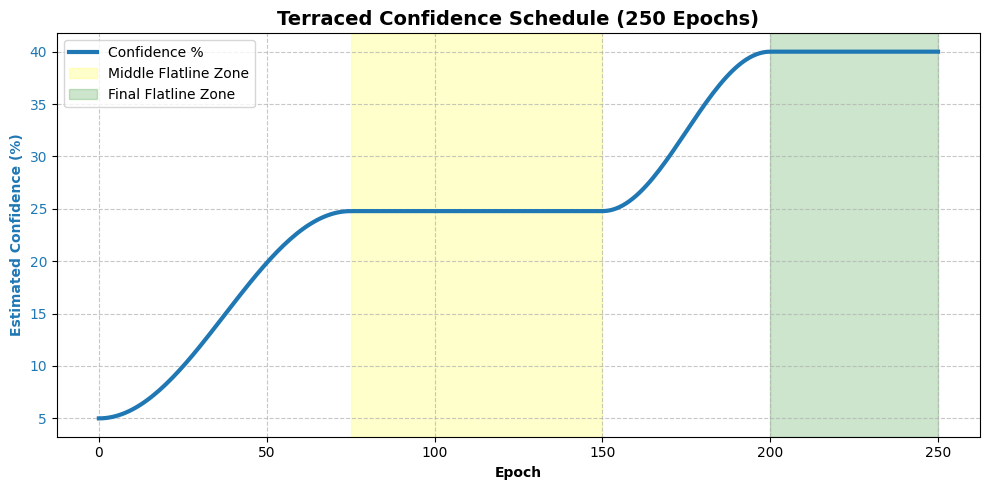

In [5]:
import math
import matplotlib.pyplot as plt

def get_tau(epoch):
    tau_start = 2.0
    tau_mid = 1.35   # Targets ~25% Confidence for the middle flatline
    tau_end = 0.85   # Targets ~40% Confidence for the final floor

    if epoch < 75:
        # Phase 1: Smooth descent to the middle flatline
        progress = epoch / 75.0
        return tau_mid + 0.5 * (tau_start - tau_mid) * (1 + math.cos(math.pi * progress))
        
    elif epoch < 150:
        # Phase 2: THE MIDDLE FLATLINE (Epoch 75 to 150)
        return tau_mid
        
    elif epoch < 200:
        # Phase 3: Smooth descent to the final floor
        progress = (epoch - 150) / 50.0
        return tau_end + 0.5 * (tau_mid - tau_end) * (1 + math.cos(math.pi * progress))
        
    else:
        # Phase 4: THE FINAL FLATLINE (Epoch 200 to 250+)
        return tau_end

# Maps tau values to the actual Confidence % you saw in your logs
def estimate_confidence(tau):
    confidence = 5.0 + (2.0 - tau) * 30.43
    return confidence

# Generate data for 251 epochs
epochs = list(range(251))
taus = [get_tau(e) for e in epochs]
confs = [estimate_confidence(t) for t in taus]

# 1. Print the Percentage Table
print(f"{'Epoch':<6} | {'Tau':<6} | {'Est. Confidence %':<17} | {'Phase'}")
print("-" * 55)
for epoch in range(251):
    if epoch % 10 == 0 or epoch in [75, 150, 200]:
        t = get_tau(epoch)
        c = estimate_confidence(t)
        
        phase = "Descent"
        if 75 <= epoch < 150: phase = "MIDDLE FLATLINE (L2 Balancing)"
        elif epoch >= 200: phase = "FINAL FLATLINE (Deep Learning)"
        
        print(f"{epoch:<6} | {t:.4f} | {c:>15.2f}% | {phase}")

# 2. Plot the Terraced Curve
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Estimated Confidence (%)', color='tab:blue', fontweight='bold')
ax1.plot(epochs, confs, color='tab:blue', linewidth=3, label='Confidence %')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Highlight the flatline zones
ax1.axvspan(75, 150, color='yellow', alpha=0.2, label='Middle Flatline Zone')
ax1.axvspan(200, 250, color='green', alpha=0.2, label='Final Flatline Zone')

plt.title("Terraced Confidence Schedule (250 Epochs)", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch

# --- 0. RECALCULATE M (The Missing Step) ---
# We use the final 'C' from your training loop and your 'A_skip_csr'
with torch.no_grad():
    A_skip_gpu = A_skip_csr.to(C.device) 
    M_tensor = torch.matmul(C.t(), torch.sparse.mm(A_skip_gpu, C))
    M_dense = M_tensor.cpu().numpy()


# --- 1. Extract Data from Tensors ---
# Get the "hard" cluster assignment for each node by finding the max probability
C_probs = C.detach().cpu().numpy()
hard_assignments = np.argmax(C_probs, axis=1)

# Extract X and Y coordinates (columns 0 and 1 in your X_float)
x_coords = X_float[:, 0].cpu().numpy()
y_coords = X_float[:, 1].cpu().numpy()

# --- 2. Identify the Top Clusters ---
# Count how many nodes belong to each cluster
unique_clusters, counts = np.unique(hard_assignments, return_counts=True)

# Sort to find the indices of the largest clusters
top_cluster_indices = np.argsort(-counts)[:10]
top_clusters = unique_clusters[top_cluster_indices]

print(f"Visualizing Top 10 Clusters: {top_clusters}")
print(f"Sizes of Top 10 Clusters: {counts[top_cluster_indices]}")

# =========================================================
# PLOT 1: SPATIAL TERRITORIES (The Physical Layout)
# =========================================================
plt.figure(figsize=(12, 10))

# 1. Plot all gates as faint gray background noise
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.1, label='Unassigned/Minor Clusters')

# 2. Plot the top 10 clusters in distinct colors
cmap = plt.get_cmap('tab10')
for i, cluster_id in enumerate(top_clusters):
    # Create a boolean mask for nodes in this specific cluster
    mask = (hard_assignments == cluster_id)
    plt.scatter(x_coords[mask], y_coords[mask], s=8, color=cmap(i), alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Spatial Territories of Top 10 Supernodes", fontsize=14)
plt.xlabel("Normalized X Coordinate")
plt.ylabel("Normalized Y Coordinate")
# Increase marker size in legend so it's readable
plt.legend(markerscale=4, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: SUPERNODE CONNECTIVITY (The Timing Highways)
# =========================================================
plt.figure(figsize=(12, 10))

# Plot the faint background map again for spatial context
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.05)

# Build a NetworkX graph to draw the connections
G = nx.Graph()
pos = {} # Dictionary to store the (x,y) center of each supernode

# 1. Calculate the spatial centroid of each top cluster
for cluster_id in top_clusters:
    mask = (hard_assignments == cluster_id)
    # The centroid is the average X and Y of all gates in the cluster
    centroid_x = np.mean(x_coords[mask])
    centroid_y = np.mean(y_coords[mask])
    
    pos[cluster_id] = (centroid_x, centroid_y)
    G.add_node(cluster_id)

# 2. Add edges based on the M matrix (Timing Connections)
# We calculate a threshold so we only draw the most important "highways"
sub_M = M_dense[np.ix_(top_clusters, top_clusters)]
# If all values are 0 (no timing connections between top 10), avoid threshold error
if sub_M.max() > 0:
    threshold = np.percentile(sub_M[sub_M > 0], 50) # Only keep top 50% of connections
    
    for i in top_clusters:
        for j in top_clusters:
            if i < j: # Prevent drawing duplicate undirected edges
                weight = M_dense[i, j]
                if weight > threshold:
                    G.add_edge(i, j, weight=weight)

# 3. Draw the Graph
edges = G.edges(data=True)
if len(edges) > 0:
    # Scale the line thickness based on how strong the M matrix connection is
    max_weight = max([d['weight'] for u, v, d in edges])
    edge_widths = [(d['weight'] / max_weight) * 5 for u, v, d in edges] 

    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='blue', alpha=0.6)

nx.draw_networkx_nodes(G, pos, node_color='red', node_size=150, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold')

plt.title("Supernode Timing Highways (M Matrix Connectivity)", fontsize=14)
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'A_skip_csr' is not defined

In [ ]:
# C[1] is the row for node 1 (size [num_clusters])
max_index = torch.argmax(C[1])
print(C[2].max())
print(max_index)

max_index2 = torch.argmax(C[2])
print(max_index2)

tensor(0.3417, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(759, device='cuda:0')
tensor(704, device='cuda:0')
